In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_rows = 100
pd.options.display.max_columns = 30
pd.options.display.max_colwidth = None


In [ ]:
regestration_fuel = pd.read_parquet(r"vahan-vehicle-registrations-by-fuel-type.parquet",parse_dates=['date'])

In [4]:
regestration_fuel.drop(columns=['category'])
print()

# Regesteration by fuel

In [5]:
regestration_fuel.drop_duplicates(inplace=True)

In [6]:
regestration_fuel.columns

Index(['id', 'date', 'state_name', 'state_code', 'office_name', 'office_code',
       'fuel_type', 'category', 'registrations'],
      dtype='str')

In [7]:
print('column Description->')
for col in regestration_fuel.describe(include=str).columns:
    print(col)
    print(regestration_fuel[col].unique())
    print('`'*100)

column Description->
state_name
<ArrowStringArray>
[                 'Andaman And Nicobar Islands',
                               'Andhra Pradesh',
                            'Arunachal Pradesh',
                                        'Assam',
                                        'Bihar',
                                   'Chandigarh',
                                 'Chhattisgarh',
                                        'Delhi',
                                          'Goa',
                                      'Gujarat',
                                      'Haryana',
                             'Himachal Pradesh',
                            'Jammu And Kashmir',
                                    'Jharkhand',
                                    'Karnataka',
                                       'Kerala',
                                       'Ladakh',
                               'Madhya Pradesh',
                                  'Maharashtra',
                  

In [8]:
regestration_fuel.info()

<class 'pandas.DataFrame'>
RangeIndex: 418372 entries, 0 to 418371
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   id             418372 non-null  int64         
 1   date           418372 non-null  datetime64[us]
 2   state_name     418372 non-null  str           
 3   state_code     418372 non-null  int64         
 4   office_name    418372 non-null  str           
 5   office_code    418372 non-null  str           
 6   fuel_type      418372 non-null  str           
 7   category       418372 non-null  str           
 8   registrations  418372 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 44.3 MB


In [9]:
regestration_fuel['registrations'] =regestration_fuel['registrations'].astype(int)

In [10]:
fuel_type = regestration_fuel.groupby(['fuel_type'])['registrations'].sum().sort_values(ascending=False).reset_index()
fuel_type

,fuel_type,registrations
0,Petrol,641613521
1,Diesel,83917468
2,Electric(Bov),17524732
3,Petrol/Cng,11795314
4,Cng Only,5534760
5,Petrol/Hybrid,5212921
6,Not Applicable,2670391
7,Petrol/Ethanol,1705860
8,Petrol/Lpg,1164050
9,Lpg Only,502721


In [11]:
fuel_state_pivottable = pd.pivot_table(regestration_fuel,index='state_name',values='registrations',columns='fuel_type',aggfunc='sum')
fuel_state_pivottable

fuel_type,Cng Only,Diesel,Diesel/Hybrid,Dual Diesel/Bio Cng,Dual Diesel/Cng,Dual Diesel/Lng,Electric(Bov),Ethanol,Fuel Cell Hydrogen,Lng,Lpg Only,Methanol,Not Applicable,Petrol,Petrol/Cng,Petrol/Ethanol,Petrol/Hybrid,Petrol/Lpg,Plug-In Hybrid Ev,Pure Ev,Solar,Strong Hybrid Ev
state_name,,,,,,,,,,,,,,,,,,,,,,
Andaman And Nicobar Islands,NaN,"3,311.00",NaN,NaN,NaN,NaN,208.00,NaN,NaN,NaN,NaN,NaN,39.00,"35,611.00",NaN,296.00,327.00,1.00,NaN,NaN,NaN,1.00
Andhra Pradesh,"1,264,062.00","18,892,850.00","11,906.00",3.00,59.00,2.00,"3,572,452.00",17.00,NaN,59.00,"106,599.00",12.00,"635,157.00","146,470,261.00","2,498,467.00","26,131.00","1,102,922.00","228,000.00",NaN,355.00,3.00,166.00
Arunachal Pradesh,"928,348.00","8,987,786.00","6,172.00",1.00,19.00,1.00,"3,013,603.00",5.00,NaN,272.00,"64,534.00",4.00,"264,803.00","67,327,425.00","1,452,640.00","382,750.00","738,968.00","75,106.00",NaN,NaN,1.00,5.00
Assam,"1,013.00","244,041.00",300.00,NaN,NaN,NaN,"160,833.00",1.00,NaN,NaN,1.00,NaN,"10,413.00","2,354,933.00",194.00,"39,685.00","21,277.00",3.00,NaN,817.00,NaN,44.00
Bihar,"108,318.00","2,575,592.00","3,425.00",1.00,NaN,NaN,"357,543.00",11.00,NaN,3.00,"14,673.00",3.00,"116,889.00","21,306,418.00","254,799.00","25,895.00","104,907.00","40,069.00",NaN,"1,014.00",1.00,60.00
Chandigarh,644.00,"39,414.00",332.00,NaN,NaN,NaN,"13,187.00",NaN,NaN,NaN,NaN,NaN,NaN,"171,616.00","3,263.00",373.00,"8,355.00",NaN,NaN,26.00,NaN,71.00
Chhattisgarh,7.00,"351,528.00",625.00,NaN,NaN,NaN,"86,900.00",1.00,NaN,NaN,331.00,NaN,"32,925.00","2,450,943.00",28.00,"5,535.00","26,938.00",712.00,NaN,397.00,NaN,79.00
Delhi,"168,276.00","1,906,545.00","3,827.00",1.00,NaN,NaN,"339,805.00",3.00,NaN,3.00,"8,590.00",2.00,"63,660.00","16,469,628.00","386,601.00","11,034.00","140,923.00","37,924.00",NaN,821.00,NaN,957.00
Goa,641.00,"21,249.00",273.00,NaN,NaN,NaN,"22,107.00",NaN,NaN,NaN,NaN,NaN,13.00,"289,372.00","2,342.00","10,000.00","8,683.00",3.00,NaN,82.00,NaN,31.00


In [12]:
label_font = {'font':'Arial','fontsize':15,'color':'k'}
text_font = {'font':'calibri','fontsize':9,'color':'k'}
title = {'font':'Noto Sans','fontsize':25,'color':'k'}

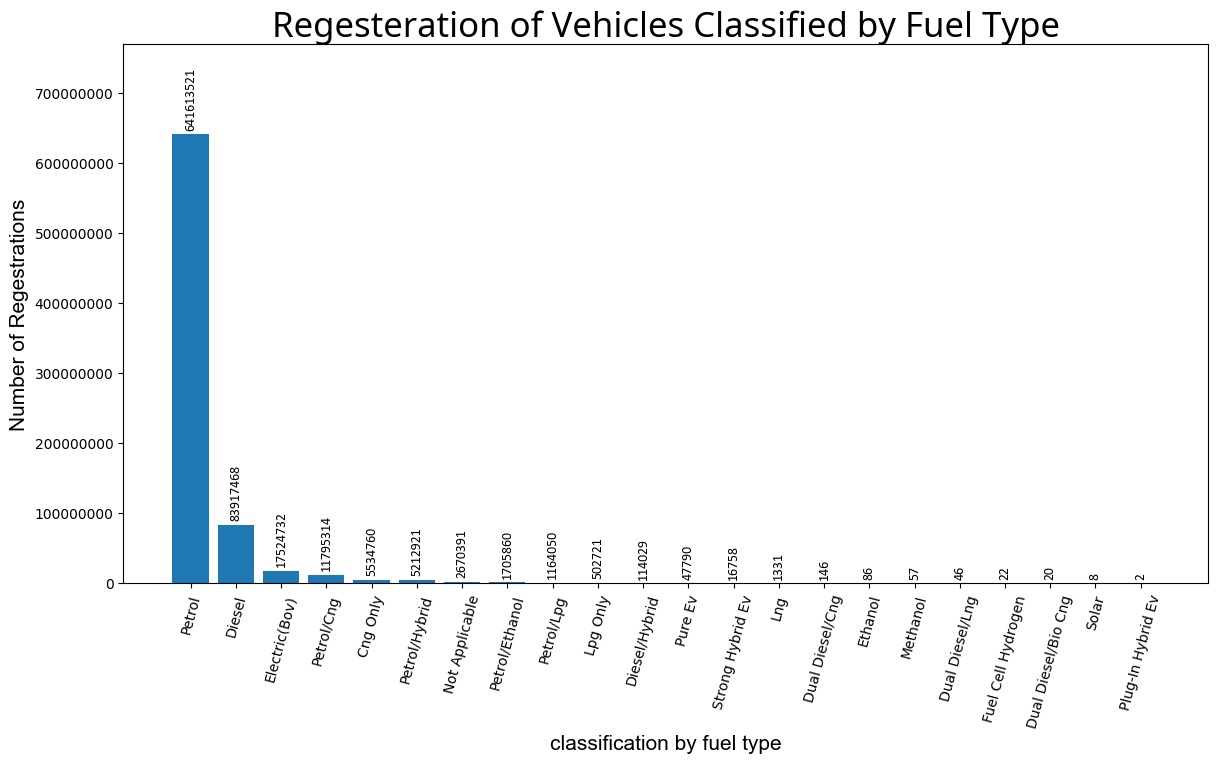

In [13]:
plt.figure(figsize=(14,7))
bar = plt.bar(fuel_type['fuel_type'],fuel_type['registrations'])
plt.xticks(rotation=75)
plt.bar_label(bar,labels=fuel_type['registrations'],rotation=90,padding=3,font='calibri',fontsize=10)
plt.ticklabel_format(style='plain',axis='y')
plt.xlabel('classification by fuel type',fontdict=label_font)
plt.ylabel('Number of Regestrations',fontdict=label_font)
plt.ylim(0,fuel_type['registrations'].max()*1.2)
plt.title('Regesteration of Vehicles Classified by Fuel Type',fontdict=title)
#plt.tight_layout()
plt.show()

### classification of fuel types

In [14]:
def classify_fuel(fuel):
    fuel = str(fuel).strip()
    
    fossil = [
        'Diesel', 'Petrol', 'Cng Only', 'Lpg Only', 'Lng', 
        'Petrol/Cng', 'Petrol/Lpg', 'Dual Diesel/Cng', 'Dual Diesel/Lng'
    ]
    hybrid = [
        'Petrol/Hybrid', 'Diesel/Hybrid', 'Strong Hybrid Ev', 'Plug-In Hybrid Ev'
    ]
    electric = [
        'Pure Ev', 'Electric(Bov)', 'Solar', 'Fuel Cell Hydrogen'
    ]
    bio = [
        'Ethanol', 'Methanol', 'Petrol/Ethanol', 'Dual Diesel/Bio Cng'
    ]
    
    if fuel in fossil:
        return 'Fossil'
    elif fuel in hybrid:
        return 'Hybrid'
    elif fuel in electric:
        return 'Electric'
    elif fuel in bio:
        return 'Bio'
    else:
        return 'Other'


regestration_fuel['classification'] = regestration_fuel['fuel_type'].apply(classify_fuel)

In [15]:
fueltype_classification_pivot_table = pd.pivot_table(regestration_fuel,values='registrations',index='state_name',columns='classification',aggfunc='sum')
fueltype_classification_pivot_table

classification,Bio,Electric,Fossil,Hybrid,Other
state_name,,,,,
Andaman And Nicobar Islands,296.00,208.00,"38,923.00",328.00,39.00
Andhra Pradesh,"26,163.00","3,572,810.00","169,460,359.00","1,114,994.00","635,157.00"
Arunachal Pradesh,"382,760.00","3,013,604.00","78,836,131.00","745,145.00","264,803.00"
Assam,"39,686.00","161,650.00","2,600,185.00","21,621.00","10,413.00"
Bihar,"25,910.00","358,558.00","24,299,872.00","108,392.00","116,889.00"
Chandigarh,373.00,"13,213.00","214,937.00","8,758.00",NaN
Chhattisgarh,"5,536.00","87,297.00","2,803,549.00","27,642.00","32,925.00"
Delhi,"11,040.00","340,626.00","18,977,567.00","145,707.00","63,660.00"
Goa,"10,000.00","22,189.00","313,607.00","8,987.00",13.00


In [16]:
fuel_class = regestration_fuel.groupby(['classification'])['registrations'].sum().sort_values(ascending=False).reset_index()
fuel_class['%']= fuel_class['registrations']/fuel_class['registrations'].sum()*100

In [17]:
fuel_class

,classification,registrations,%
0,Fossil,744529357,96.46
1,Electric,17572552,2.28
2,Hybrid,5343710,0.69
3,Other,2670391,0.35
4,Bio,1706023,0.22


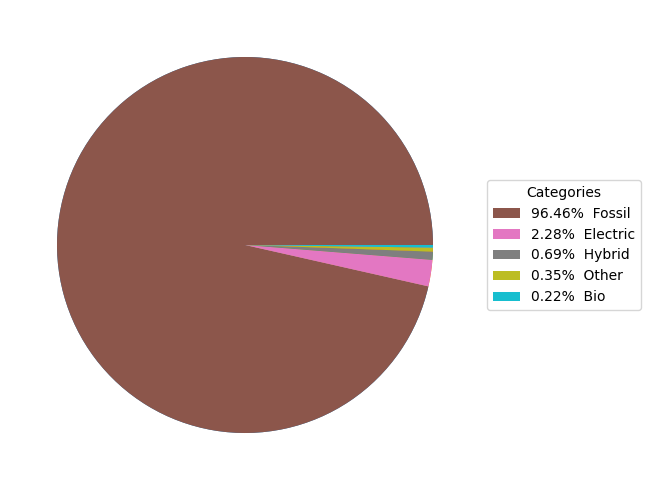

In [18]:
pie_lables = fuel_class['%'].round(2).astype(str)+'%'+'  '+fuel_class['classification']
plt.figure(figsize=(7,5))
plt.pie(fuel_class['registrations'])
w,t = plt.pie(fuel_class['registrations'])
plt.legend(w,pie_lables,title='Categories',loc='center left',bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

### Ev Addoption over year 

In [19]:
regestration_fuel['year'] = regestration_fuel['date'].dt.year
ev_by_year = regestration_fuel[regestration_fuel['classification']=='Electric'].groupby(['year'])['registrations'].sum().reset_index()
ev_by_year['growth_%'] = ev_by_year['registrations'].pct_change()* 100
ev_by_year.fillna(0,inplace=True)
ev_by_year


,year,registrations,growth_%
0,2019,168620,0.00
1,2020,2595161,"1,439.06"
2,2021,2316147,-10.75
3,2022,6232358,169.08
4,2023,4703986,-24.52
5,2024,1556280,-66.92


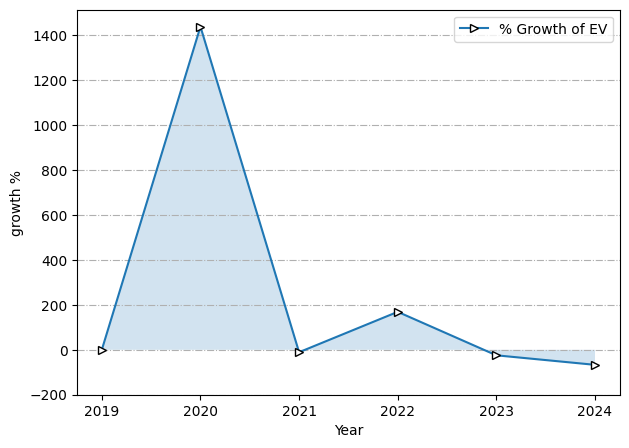

In [20]:
plt.figure(figsize=(7,5))
plt.plot(ev_by_year['year'],ev_by_year['growth_%'],marker='>',mfc='w',mec='k',label='% Growth of EV')
plt.fill_between(ev_by_year['year'],ev_by_year['growth_%'],alpha=0.2)
plt.xlabel('Year')
plt.ylabel('growth %')
plt.legend()
plt.grid(axis='y',linestyle='-.')
plt.ylim(-200,)
plt.show()


In [21]:
electric_vhicle = regestration_fuel[regestration_fuel['classification']=='Electric'].groupby(['date'])['registrations'].sum().reset_index()
electric_vhicle['date'] = electric_vhicle['date'].dt.strftime('%B-%Y')

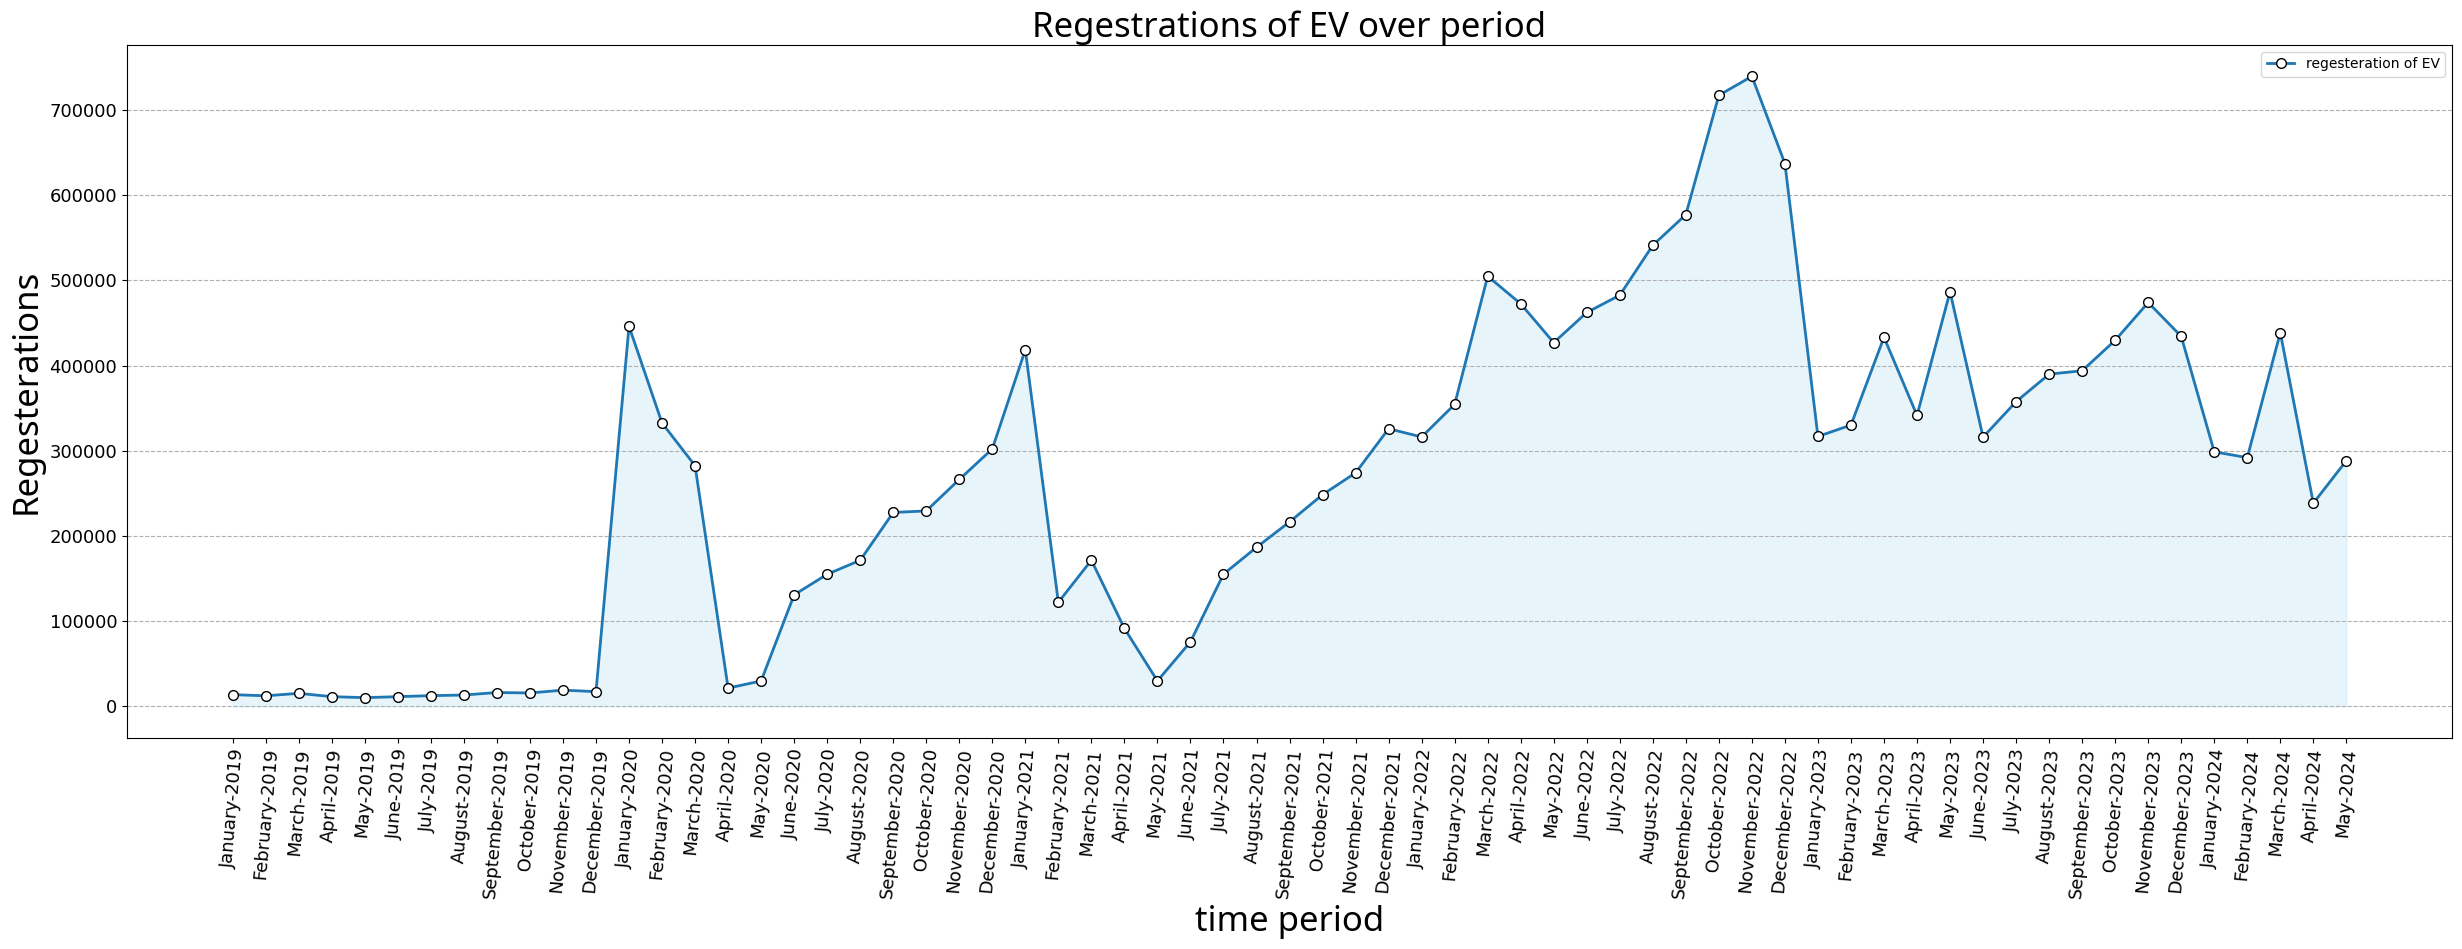

In [22]:
plt.figure(figsize=(30,9))
plt.grid(axis='y',linestyle='--')
plt.plot(electric_vhicle['date'].astype(str),electric_vhicle['registrations'],marker='o',ms=7,mfc='w',mec='k',label='regesteration of EV',linewidth=2)
plt.fill_between(electric_vhicle['date'],electric_vhicle['registrations'],alpha=0.2,color='skyblue')
plt.xticks(rotation=85,fontsize=13)
plt.yticks(fontsize=13)
plt.xlabel('time period',fontdict=title)
plt.ylabel('Regesterations',fontdict=title)
plt.legend()
plt.title('Regestrations of EV over period',fontdict=title)
plt.show()

In [23]:
ev_state = regestration_fuel[(regestration_fuel['classification']=='Electric')].groupby(['state_name'])['registrations'].sum().sort_values(ascending=False).reset_index().head(10)


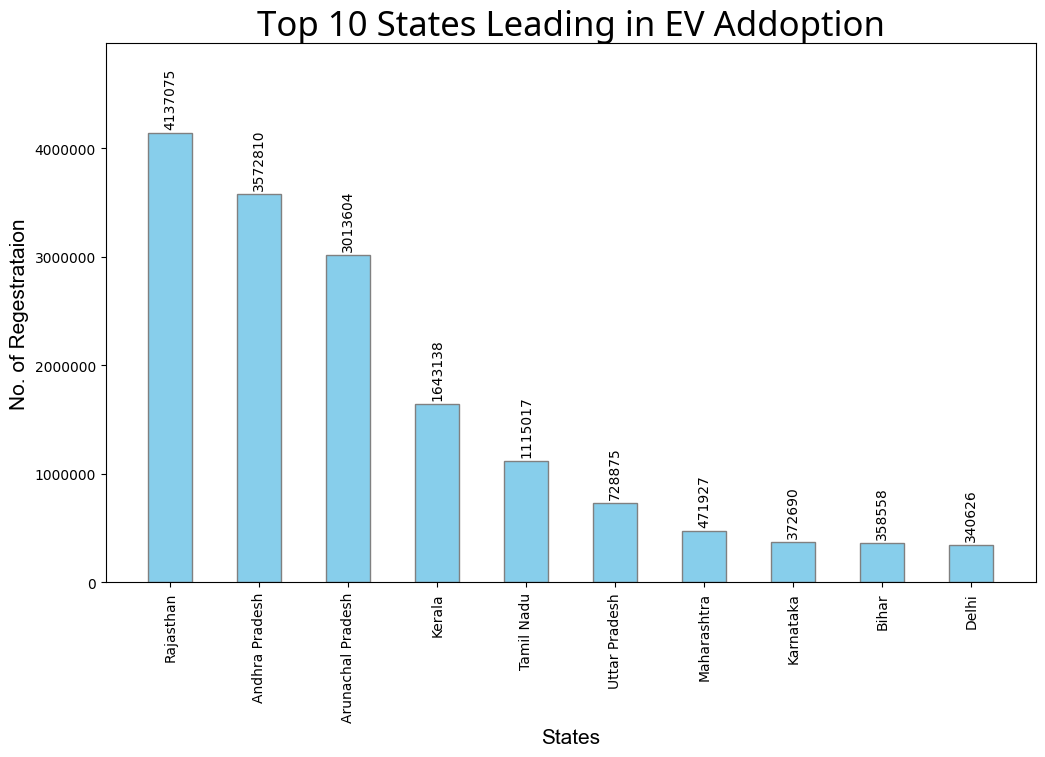

In [24]:
plt.figure(figsize=(12,7))
bar = plt.bar(ev_state['state_name'],ev_state['registrations'],color='skyblue',edgecolor='grey',width=.5)

plt.ticklabel_format(style='plain',axis='y')
plt.bar_label(bar,labels=ev_state['registrations'],rotation=90,padding=3)
plt.xlabel('States',fontdict=label_font)
plt.ylabel('No. of Regestrataion',fontdict=label_font)
plt.title('Top 10 States Leading in EV Addoption',fontdict=title)
plt.ylim(0,ev_state['registrations'].max()*1.2)
plt.xticks(rotation=90)
plt.show()


## EV regestration by year

In [25]:
states_ev_pivot= pd.pivot_table(regestration_fuel[regestration_fuel['classification']=='Electric'],values='registrations',index='year',columns='state_name',aggfunc='sum',).reset_index()

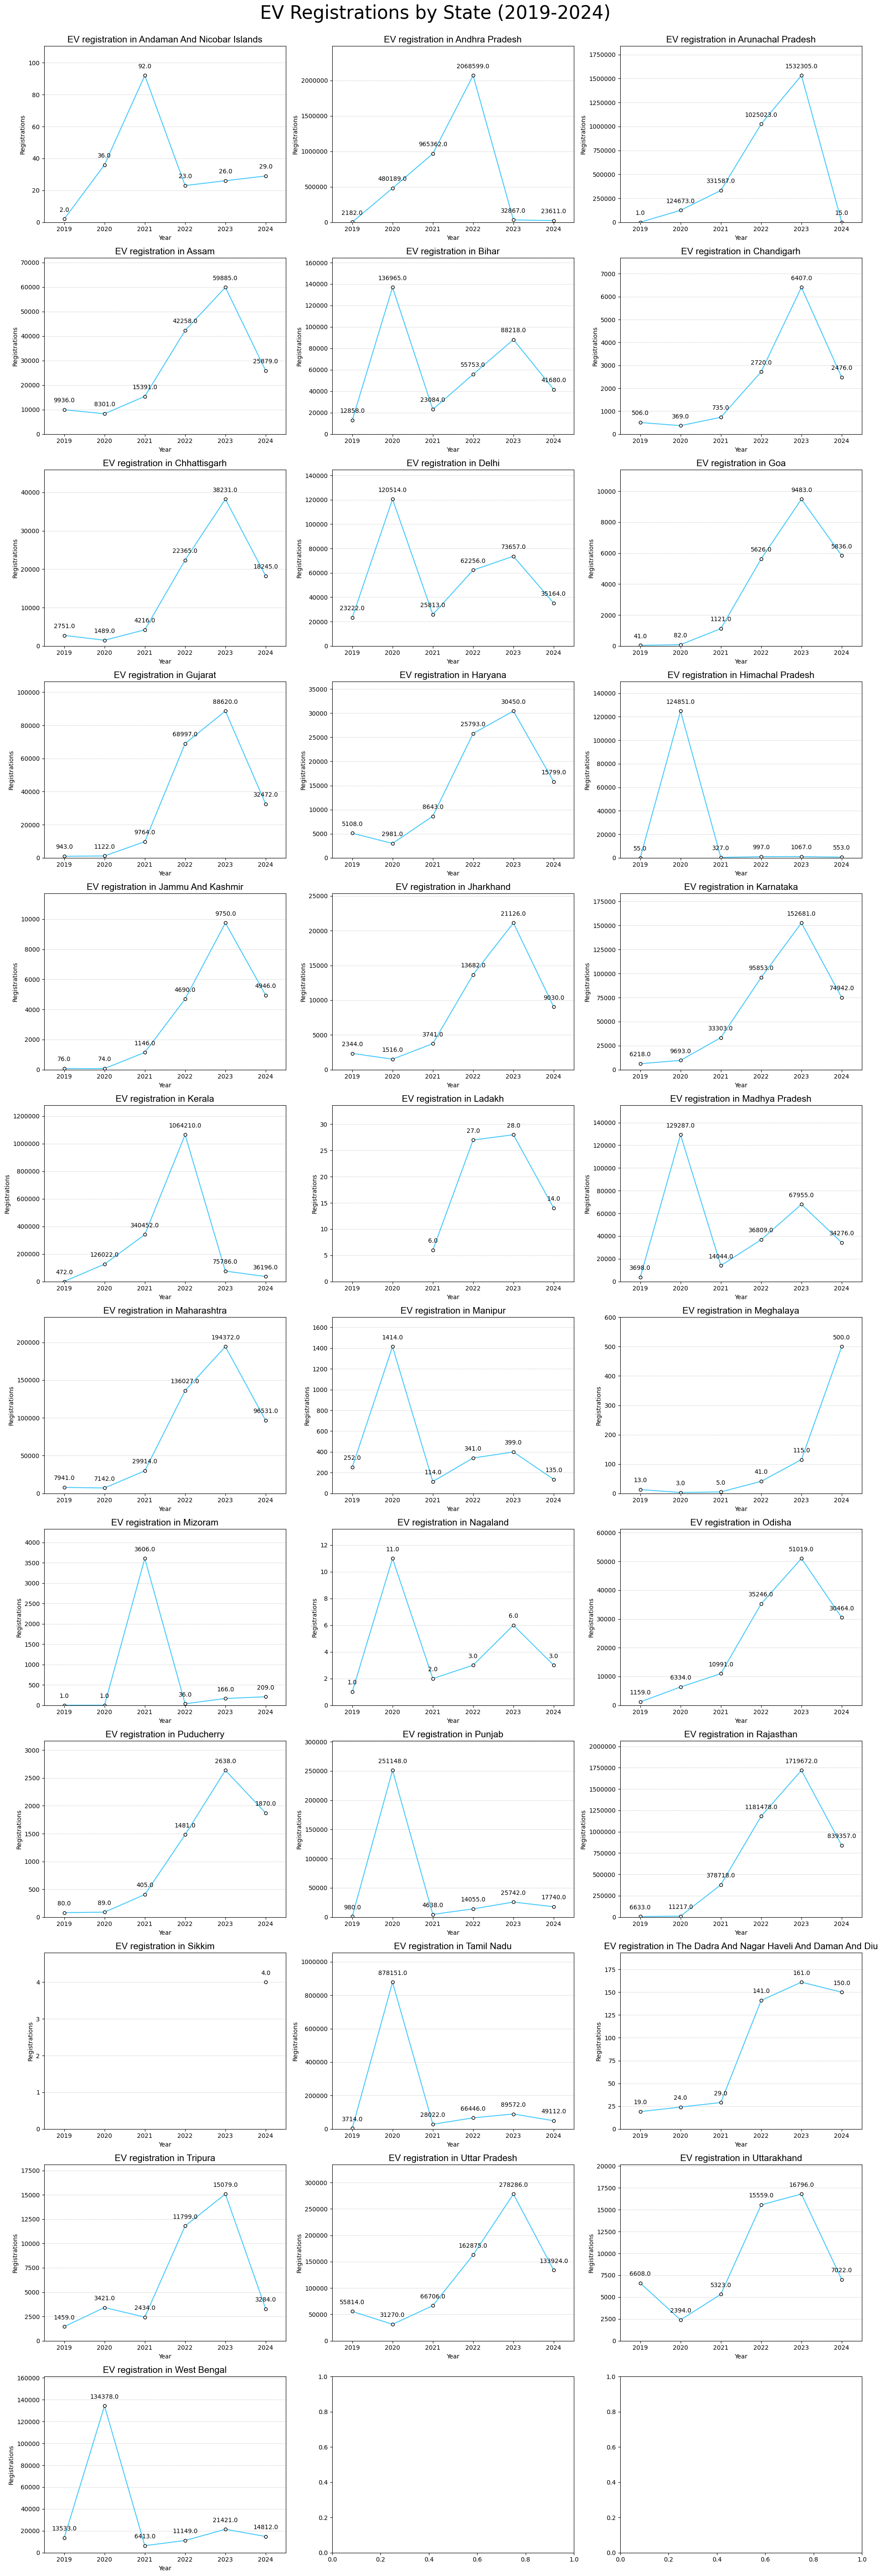

In [26]:
'''for col in states_ev_pivot.columns:
    if col == 'year':
        pass
    else:
        plt.figure(figsize=(10,5))
        plt.plot(states_ev_pivot['year'],states_ev_pivot[col],marker='o',mfc='w',mec='k',ms=5,color='skyblue')
        plt.xlabel('Year')
        plt.ylabel('Registerations')
        plt.title(f'EV registeration in {col} from 2019-2024',fontdict=label_font)
        plt.ticklabel_format(style='plain')
        for i, v in zip(states_ev_pivot['year'],states_ev_pivot[col]):
            plt.text(i,v+states_ev_pivot[col].max()*0.05,f'{v}')
        plt.ylim(0,states_ev_pivot[col].max()*1.2)
        plt.xlim(2018.5,2024.5)
        plt.grid(axis='y',linestyle=':')
        plt.show()'''

states = [col for col in states_ev_pivot.columns if col != 'year']

rows = (len(states) + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(20, 5*rows))

axes = axes.flatten()

for ax, col in zip(axes, states):
    ax.plot(states_ev_pivot['year'], states_ev_pivot[col],
            marker='o', mfc='w', mec='k', ms=5, color='#45c9fb')
    ax.set_xlabel('Year')
    ax.set_ylabel('Registrations')
    ax.set_title(f'EV registration in {col}', fontdict=label_font)
    ax.ticklabel_format(style='plain')
    ax.set_ylim(0, states_ev_pivot[col].max()*1.2)
    ax.set_xlim(2018.5, 2024.5)
    ax.grid(axis='y', linestyle=':')

    for i, v in zip(states_ev_pivot['year'], states_ev_pivot[col]):
        ax.text(i, v + states_ev_pivot[col].max()*0.05, f'{v}', ha='center')

fig.suptitle('EV Registrations by State (2019-2024)', fontsize=30)
plt.tight_layout(rect=[0, 0, 1,0.98])
plt.show()


## EV regesteration over all

In [27]:
ev_state19 = regestration_fuel[(regestration_fuel['classification']=='Electric')&(regestration_fuel['date'].dt.year==2019)].groupby(['state_name'])['registrations'].sum().sort_values(ascending=False).reset_index().head(10)
ev_state20 = regestration_fuel[(regestration_fuel['classification']=='Electric')&(regestration_fuel['date'].dt.year==2020)].groupby(['state_name'])['registrations'].sum().sort_values(ascending=False).reset_index().head(10)
ev_state21 = regestration_fuel[(regestration_fuel['classification']=='Electric')&(regestration_fuel['date'].dt.year==2021)].groupby(['state_name'])['registrations'].sum().sort_values(ascending=False).reset_index().head(10)
ev_state22 = regestration_fuel[(regestration_fuel['classification']=='Electric')&(regestration_fuel['date'].dt.year==2022)].groupby(['state_name'])['registrations'].sum().sort_values(ascending=False).reset_index().head(10)
ev_state23 = regestration_fuel[(regestration_fuel['classification']=='Electric')&(regestration_fuel['date'].dt.year==2023)].groupby(['state_name'])['registrations'].sum().sort_values(ascending=False).reset_index().head(10)
ev_state24 = regestration_fuel[(regestration_fuel['classification']=='Electric')&(regestration_fuel['date'].dt.year==2024)].groupby(['state_name'])['registrations'].sum().sort_values(ascending=False).reset_index().head(10)

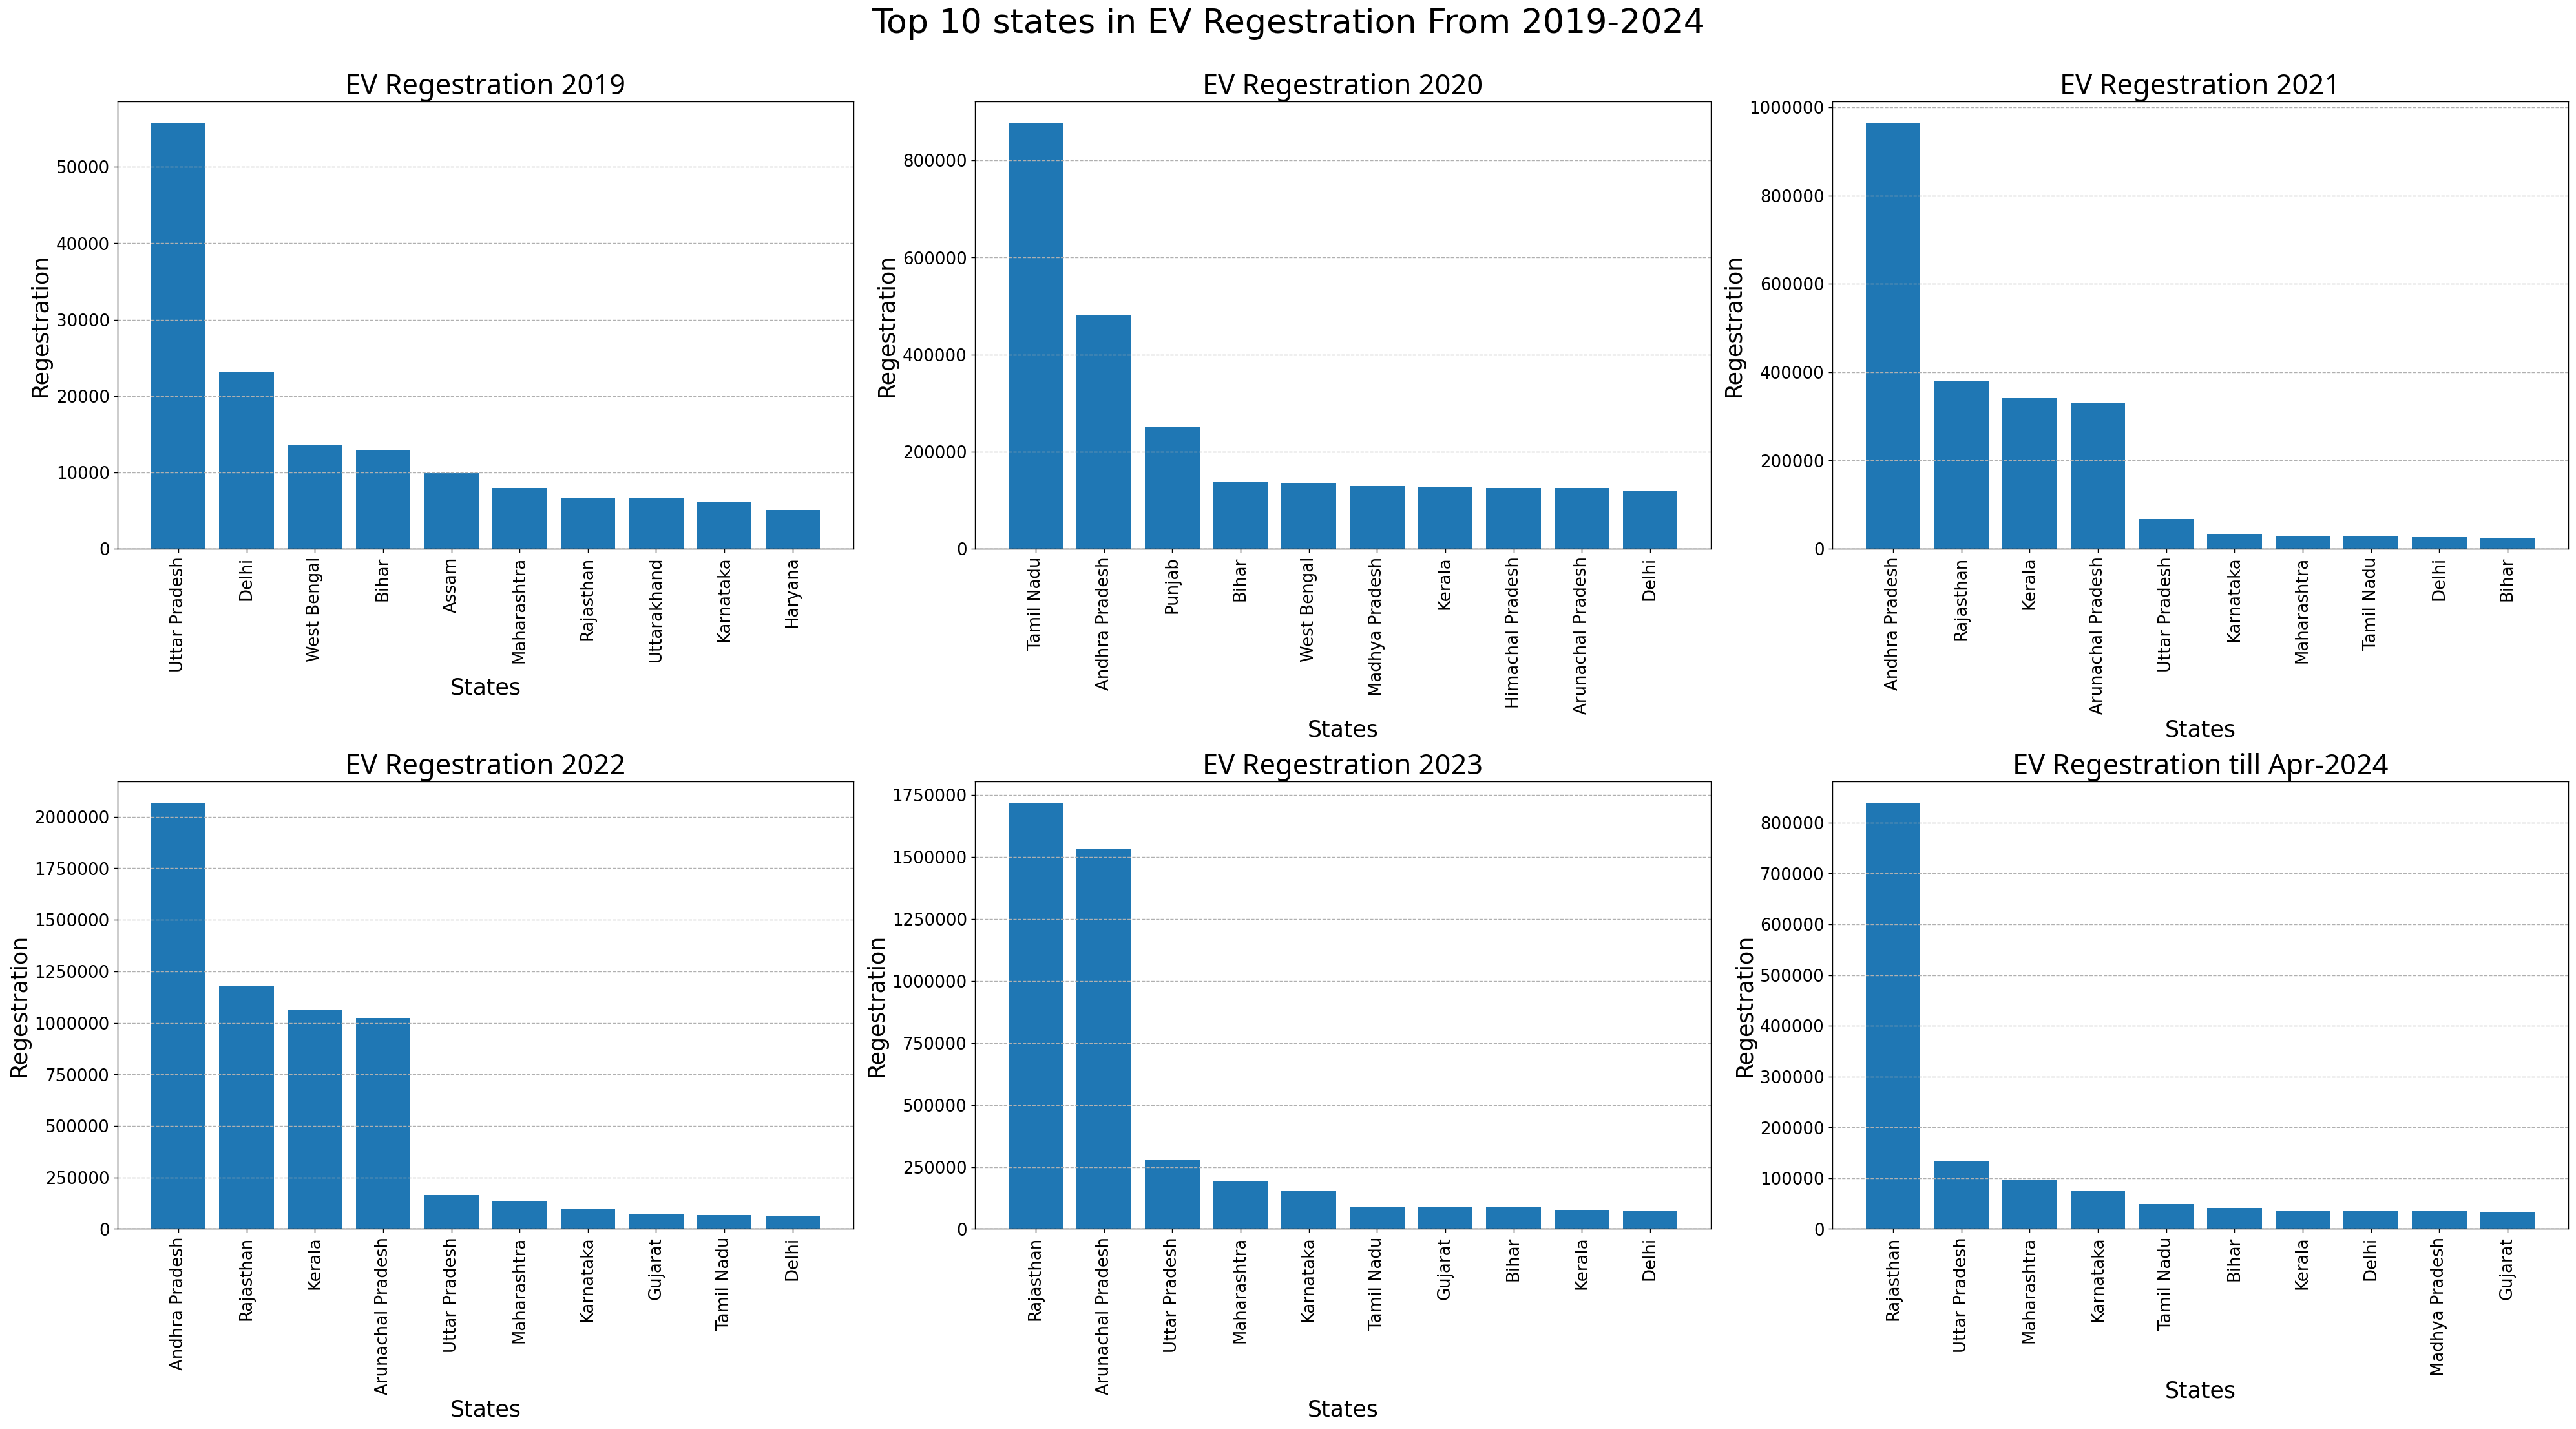

In [28]:
try:
    fig, ax = plt.subplots(2,3,figsize=(32,18),dpi=125)
    # 2019 ev regestration
    ax[0,0].bar(ev_state19['state_name'],ev_state19['registrations'])
    ax[0,0].set_xlabel('States',fontsize=20)
    ax[0,0].set_ylabel('Regestration',fontsize=20)
    ax[0,0].set_title('EV Regestration 2019',fontdict=title)
    ax[0,0].ticklabel_format(axis='y',style='plain')
    ax[0,0].grid(linestyle='--',axis='y')

    # 2020 ev regestration
    ax[0,1].bar(ev_state20['state_name'],ev_state20['registrations'])
    ax[0,1].set_xlabel('States',fontsize=20)
    ax[0,1].set_ylabel('Regestration',fontsize=20)
    ax[0,1].set_title('EV Regestration 2020',fontdict=title)
    ax[0,1].ticklabel_format(axis='y',style='plain')
    ax[0,1].grid(linestyle='--',axis='y')

    # 2021 ev regestration
    ax[0,2].bar(ev_state21['state_name'],ev_state21['registrations'])
    ax[0,2].set_xlabel('States',fontsize=20)
    ax[0,2].set_ylabel('Regestration',fontsize=20)
    ax[0,2].set_title('EV Regestration 2021',fontdict=title)
    ax[0,2].ticklabel_format(axis='y',style='plain')
    ax[0,2].grid(linestyle='--',axis='y')

    # 2022 ev regestration
    ax[1,0].bar(ev_state22['state_name'],ev_state22['registrations'])
    ax[1,0].set_xlabel('States',fontsize=20)
    ax[1,0].set_ylabel('Regestration',fontsize=20)
    ax[1,0].set_title('EV Regestration 2022',fontdict=title)
    ax[1,0].ticklabel_format(axis='y',style='plain')
    ax[1,0].grid(linestyle='--',axis='y')

    # 2023 ev regestration
    ax[1,1].bar(ev_state23['state_name'],ev_state23['registrations'])
    ax[1,1].set_xlabel('States',fontsize=20)
    ax[1,1].set_ylabel('Regestration',fontsize=20)
    ax[1,1].set_title('EV Regestration 2023',fontdict=title)
    ax[1,1].ticklabel_format(axis='y',style='plain')
    ax[1,1].grid(linestyle='--',axis='y')

    # 2024 ev regestration
    ax[1,2].bar(ev_state24['state_name'],ev_state24['registrations'])
    ax[1,2].set_xlabel('States',fontsize=20)
    ax[1,2].set_ylabel('Regestration',fontsize=20)
    ax[1,2].set_title('EV Regestration till Apr-2024',fontdict=title)
    ax[1,2].ticklabel_format(axis='y',style='plain')
    ax[1,2].grid(linestyle='--',axis='y')

    ax[0,0].tick_params(axis='x', rotation=90,labelsize=15)
    ax[0,1].tick_params(axis='x', rotation=90,labelsize=15)
    ax[0,2].tick_params(axis='x', rotation=90,labelsize=15)
    ax[1,0].tick_params(axis='x', rotation=90,labelsize=15)
    ax[1,1].tick_params(axis='x', rotation=90,labelsize=15)
    ax[1,2].tick_params(axis='x', rotation=90,labelsize=15)

    ax[0,0].tick_params(axis='y',labelsize=15)
    ax[0,1].tick_params(axis='y',labelsize=15)
    ax[0,2].tick_params(axis='y',labelsize=15)
    ax[1,0].tick_params(axis='y',labelsize=15)
    ax[1,1].tick_params(axis='y',labelsize=15)
    ax[1,2].tick_params(axis='y',labelsize=15)

    plt.suptitle('Top 10 states in EV Regestration From 2019-2024\n',fontsize=30)
    plt.tight_layout()
    plt.show()
except NameError:
    print(NameError)